# State Injection Evaluation: Full QEC vs Full Postselection vs Hybrid

This notebook evaluates three post-selection modes for state injection:
- `full_qec`
- `full_postselection`
- `hybrid`

The sweep covers:
- `injection_protocol = ['middle', 'corner']`
- `rounds = [2, 3]`
- `distance = [3, 5, 7]`
- `p = [1e-4, 5e-4, 8e-4, 1e-3, 2e-3, 5e-3]`
- `inject_state = 'Z'`
- `noise_model = 'circuit_level'`

In [1]:
import sys, os, io, contextlib
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from experiments.state_injection import StateInjectionExperiment
from src.noise.config import NoiseConfig
from src.simulation.decoder_backend import SimulationPipeline, ExperimentTask, DecoderConfig
from src.simulation.decoder_backend.post_select import get_post_select_detector_indices

## 1. d=3, rounds=2 Circuit Check (middle & corner)

Print the two circuits (`middle`, `corner`) with:
- `distance = 3`
- `rounds = 2`
- `inject_state = 'Z'`

Then summarize detector counts (`post-select` vs `total`) for each post-select mode.

Circuit: protocol=middle, d=3, rounds=2, inject_state='Z', mode='full_postselection'
QUBIT_COORDS(2, 0) 0
QUBIT_COORDS(1, 1) 1
QUBIT_COORDS(3, 1) 2
QUBIT_COORDS(5, 1) 3
QUBIT_COORDS(2, 2) 4
QUBIT_COORDS(6, 2) 5
QUBIT_COORDS(4, 2) 6
QUBIT_COORDS(1, 3) 7
QUBIT_COORDS(3, 3) 8
QUBIT_COORDS(5, 3) 9
QUBIT_COORDS(0, 4) 10
QUBIT_COORDS(4, 4) 11
QUBIT_COORDS(2, 4) 12
QUBIT_COORDS(1, 5) 13
QUBIT_COORDS(3, 5) 14
QUBIT_COORDS(5, 5) 15
QUBIT_COORDS(4, 6) 16
RX 1 2 14 15
Z_ERROR(0.001) 1 2 14 15
R 7 13 3 9 8 0 4 5 6 10 11 12 16
X_ERROR(0.001) 7 13 3 9 8 0 4 5 6 10 11 12 16
TICK[SE_start]
DEPOLARIZE1(0.001) 1 2 3 7 8 9 13 14 15
H 0 6 12 16
DEPOLARIZE1(0.001) 0 6 12 16
TICK
CX 0 2 6 9 12 14 8 4 13 10 15 11
DEPOLARIZE2(0.001) 0 2 6 9 12 14 8 4 13 10 15 11
TICK
CX 0 1 6 8 12 13 2 4 7 10 9 11
DEPOLARIZE2(0.001) 0 1 6 8 12 13 2 4 7 10 9 11
TICK
CX 6 3 12 8 16 15 7 4 9 5 14 11
DEPOLARIZE2(0.001) 6 3 12 8 16 15 7 4 9 5 14 11
TICK
CX 6 2 12 7 16 14 1 4 3 5 8 11
DEPOLARIZE2(0.001) 6 2 12 7 16 14 1 4 3 5 8 11


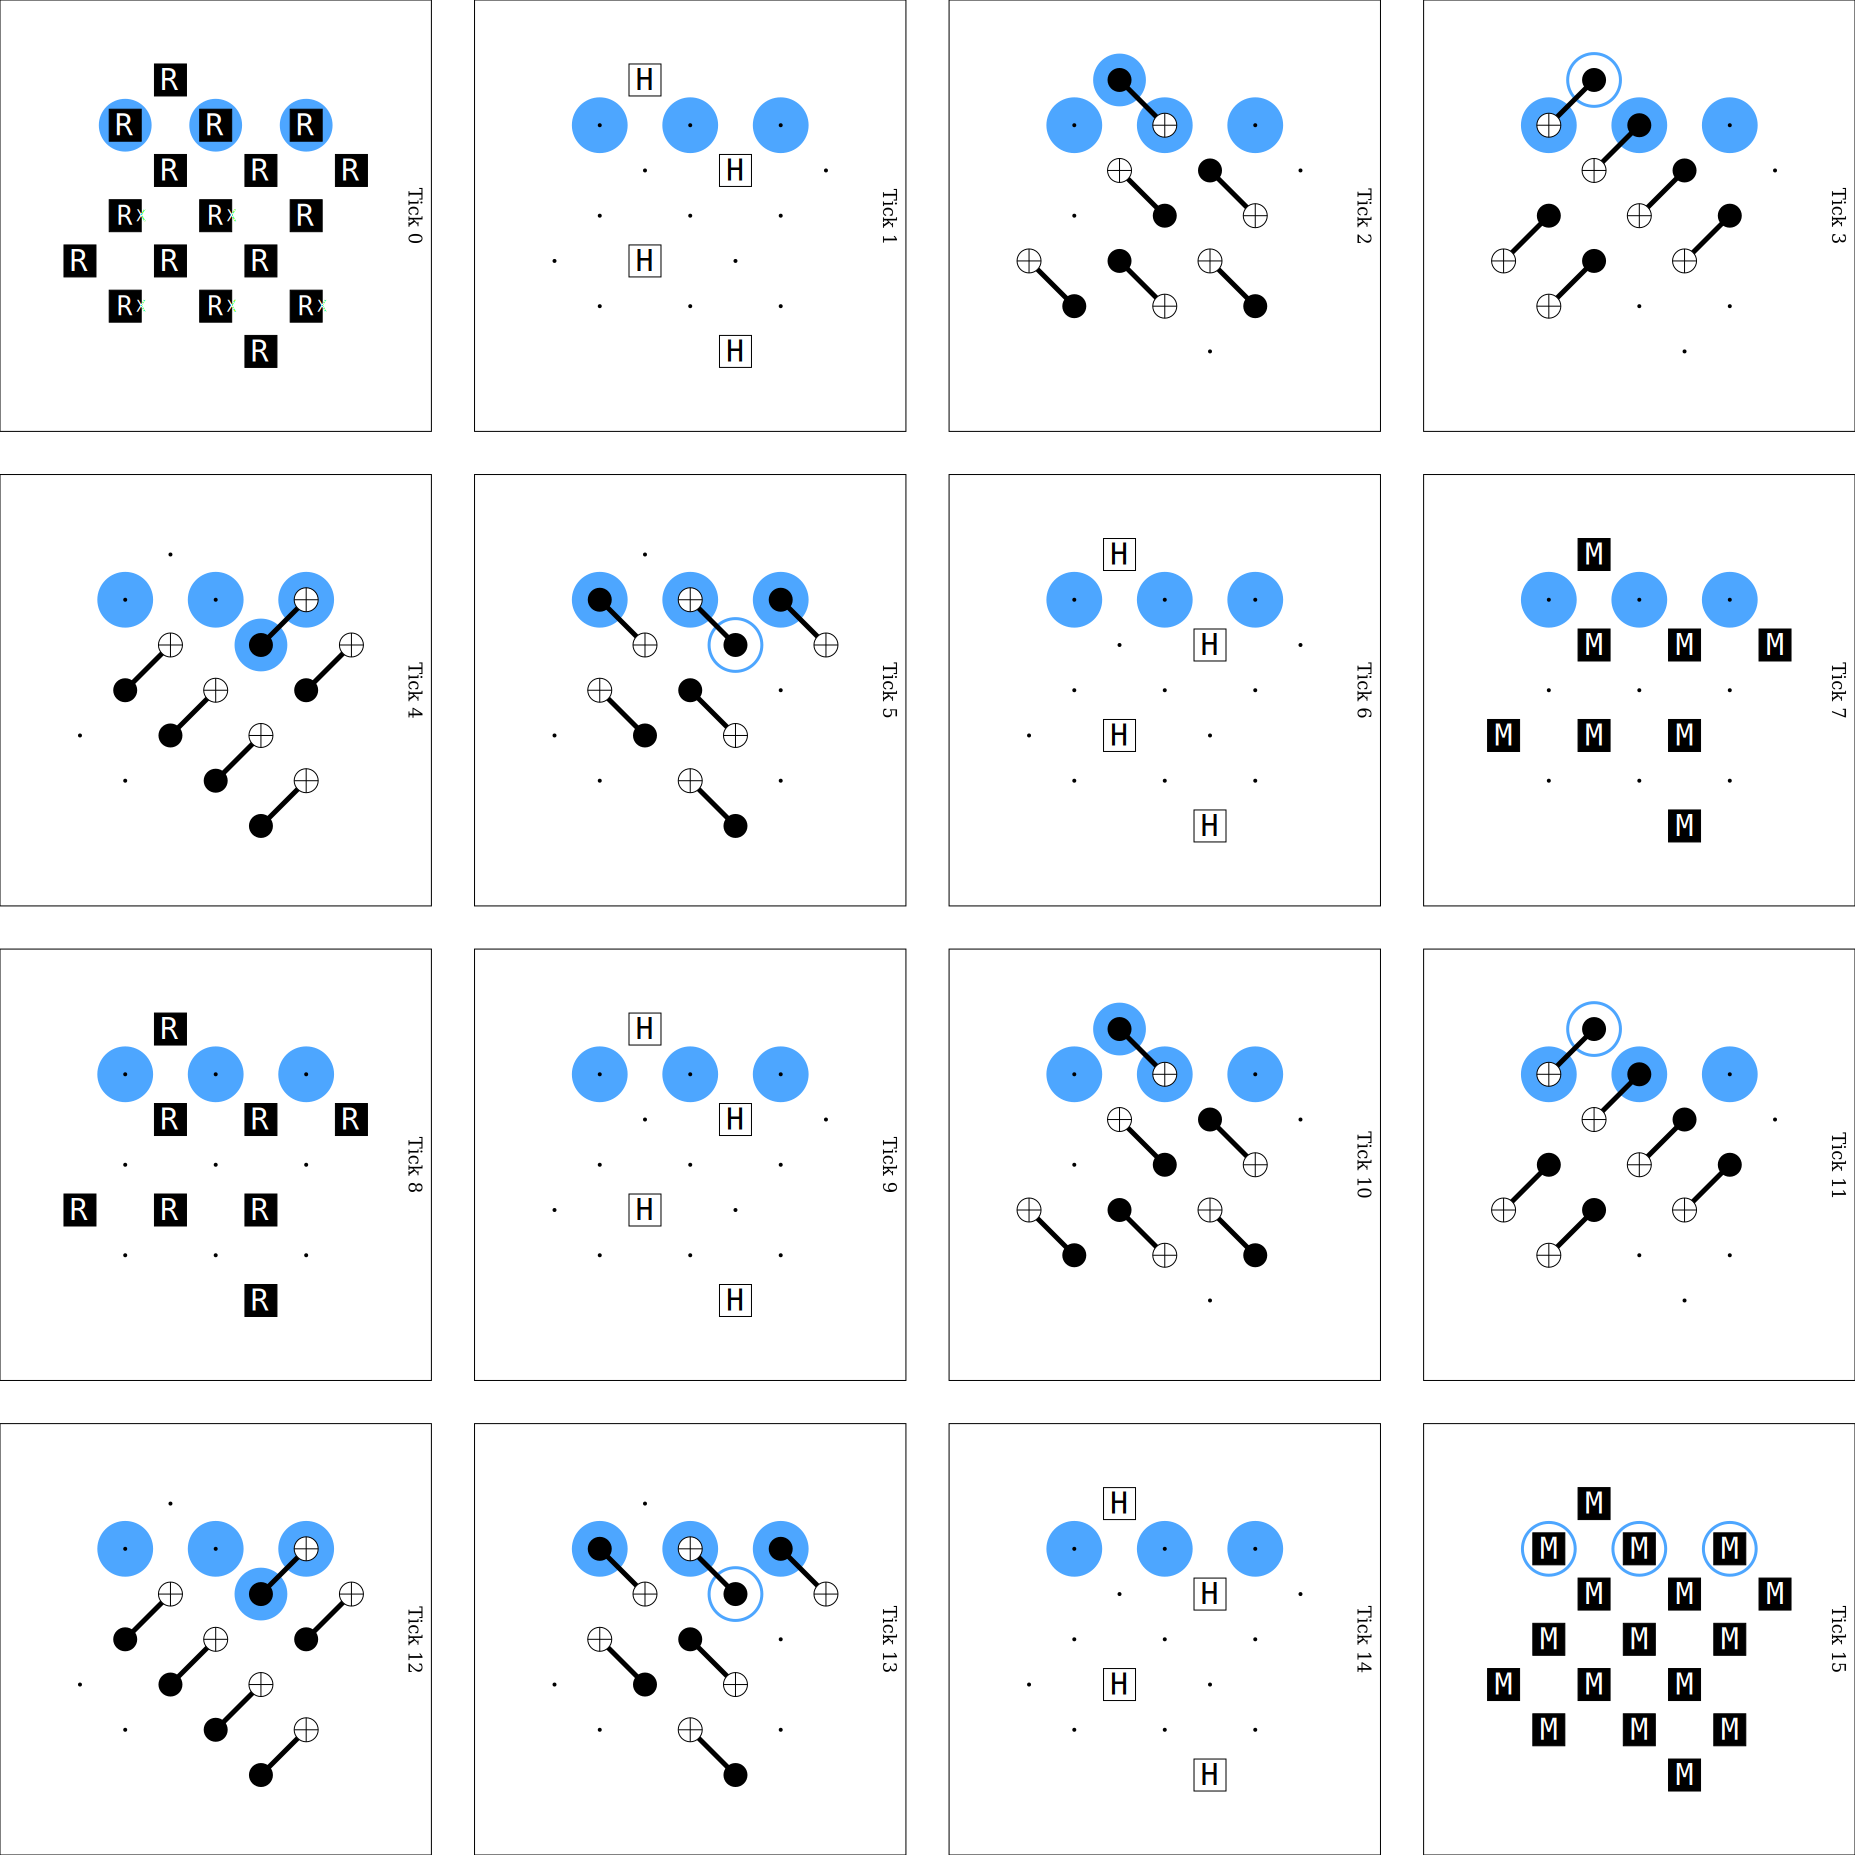

In [3]:
# Print middle/corner circuits at d=3, rounds=2, inject_state='Z'.
noise_params_demo = NoiseConfig(p_idle=1e-3, p_meas=1e-3, p_reset=1e-3, p_1q=1e-3, p_2q=1e-3)

demo_protocols = ["middle", "corner"]
demo_circuits = {}

for protocol in demo_protocols:
    with contextlib.redirect_stdout(io.StringIO()):
        exp = StateInjectionExperiment(
            distance=3,
            rounds=2,
            injection_protocol=protocol,
            post_select_mode="full_postselection",
            inject_state="Z",
            noise_params=noise_params_demo,
            noise_model="circuit_level",
        )
        circuit = exp.build()
    demo_circuits[protocol] = circuit
    print("=" * 80)
    print(f"Circuit: protocol={protocol}, d=3, rounds=2, inject_state='Z', mode='full_postselection'")
    print("=" * 80)
    print(circuit)
    print()
circuit.without_noise().diagram("detslice-with-ops-svg", filter_coords= ["L0"])

In [3]:
# Count post-select detectors and total detectors for all modes at d=3, rounds=2.
demo_modes = ["full_qec", "hybrid", "full_postselection"]
demo_records = []

for protocol in demo_protocols:
    for mode in demo_modes:
        with contextlib.redirect_stdout(io.StringIO()):
            exp = StateInjectionExperiment(
                distance=3,
                rounds=2,
                injection_protocol=protocol,
                post_select_mode=mode,
                inject_state="Z",
                noise_params=noise_params_demo,
                noise_model="circuit_level",
            )
            c = exp.build()

        ps_idx = get_post_select_detector_indices(c)
        demo_records.append(
            {
                "injection_protocol": protocol,
                "post_select_mode": mode,
                "post_select_detectors": len(ps_idx),
                "total_detectors": c.num_detectors,
            }
        )

demo_df = pd.DataFrame(demo_records).sort_values(["injection_protocol", "post_select_mode"])
demo_df

,injection_protocol,post_select_mode,post_select_detectors,total_detectors
5,corner,full_postselection,11,15
3,corner,full_qec,0,15
4,corner,hybrid,2,15
2,middle,full_postselection,12,16
0,middle,full_qec,0,16
1,middle,hybrid,4,16


## 2. Full Evaluation Sweep

Parameters:
- `injection_protocol = ['middle', 'corner']`
- `post_select_mode = ['full_qec', 'hybrid', 'full_postselection']`
- `d = [3, 5, 7]`
- `rounds = [2, 3]`
- `p = [1e-4, 5e-4, 8e-4, 1e-3, 2e-3, 5e-3]`
- `inject_state = 'Z'`
- `noise_model = 'circuit_level'`

Stopping conditions (tunable):
- `MAX_SHOTS = 1_000_000`
- `MAX_ERRORS = 100`

In [4]:
# Build tasks for full evaluation grid
INJECTION_PROTOCOLS = ["middle"]
POST_SELECT_MODES = ["full_qec", "hybrid", "full_postselection"]
DISTANCES = [3, 5, 7]
ROUNDS_LIST = [2, 3]
PER_LIST = [1e-4, 5e-4, 1e-3]

MAX_SHOTS = 1_000_000
MAX_ERRORS = 100

tasks = []
for protocol in INJECTION_PROTOCOLS:
    for rounds in ROUNDS_LIST:
        for d in DISTANCES:
            for p in PER_LIST:
                for mode in POST_SELECT_MODES:
                    noise_params = NoiseConfig(
                        p_idle=p,
                        p_meas=p,
                        p_reset=p,
                        p_1q=p,
                        p_2q=p,
                    )
                    with contextlib.redirect_stdout(io.StringIO()):
                        exp = StateInjectionExperiment(
                            distance=d,
                            rounds=rounds,
                            injection_protocol=protocol,
                            post_select_mode=mode,
                            inject_state="Z",
                            noise_params=noise_params,
                            noise_model="circuit_level",
                        )
                        circuit = exp.build()
                    tasks.append(
                        ExperimentTask(
                            circuit,
                            json_metadata={
                                "injection_protocol": protocol,
                                "post_select_mode": mode,
                                "rounds": rounds,
                                "d": d,
                                "p": p,
                            },
                        )
                    )

print(f"Built {len(tasks)} tasks")

Built 54 tasks


In [5]:
# Run simulation with PyMatching decoder
# Note: with 216 tasks this can take substantial time.
decoder_config = DecoderConfig("pymatching", backend="cpu")
pipeline = SimulationPipeline(
    decoder_config=decoder_config,
    max_errors=MAX_ERRORS,
    max_shots=MAX_SHOTS,
    num_workers=32,
    print_progress=True,
)

df = pipeline.run_batch(tasks)

df = df.sort_values(
    ["injection_protocol", "rounds", "d", "p", "post_select_mode"],
    ignore_index=True,
)

Task 1/54: {'injection_protocol': 'middle', 'post_select_mode': 'full_qec', 'rounds': 2, 'd': 3, 'p': 0.0001}
shots=0 kept=0 errors=0 LER=0.00e+00 elapsed=0.2s ETA=--
shots=0 kept=0 errors=0 LER=0.00e+00 elapsed=10.3s ETA=--
shots=0 kept=0 errors=0 LER=0.00e+00 elapsed=20.3s ETA=--
shots=0 kept=0 errors=0 LER=0.00e+00 elapsed=30.3s ETA=--
shots=150,000 kept=150,000 errors=109 LER=7.27e-04 elapsed=34.3s ETA=0s
 CTRL-C caught in cudaq runtime.
 CTRL-C caught in cudaq runtime.
 CTRL-C caught in cudaq runtime.
 CTRL-C caught in cudaq runtime.
 CTRL-C caught in cudaq runtime.
 CTRL-C caught in cudaq runtime.
 CTRL-C caught in cudaq runtime.
 CTRL-C caught in cudaq runtime.
 CTRL-C caught in cudaq runtime.
 CTRL-C caught in cudaq runtime.
 CTRL-C caught in cudaq runtime.
 CTRL-C caught in cudaq runtime.
 CTRL-C caught in cudaq runtime.
 CTRL-C caught in cudaq runtime.
 CTRL-C caught in cudaq runtime.
 CTRL-C caught in cudaq runtime.
 CTRL-C caught in cudaq runtime.
 CTRL-C caught in cudaq ru

KeyboardInterrupt: 

## 3. Results Tables

In [ ]:
# Raw long-format results
print(f"Total rows: {len(df)}")
df.head(12)

# Wide table: one row per (protocol, rounds, d, p), with 3 LER columns
ler_wide = (
    df.pivot_table(
        index=["injection_protocol", "rounds", "d", "p"],
        columns="post_select_mode",
        values="logical_error_rate",
    )
    .rename(
        columns={
            "full_qec": "ler_full_qec",
            "hybrid": "ler_hybrid",
            "full_postselection": "ler_full_postselection",
        }
    )
    .reset_index()
    .sort_values(["injection_protocol", "rounds", "d", "p"], ignore_index=True)
)

# Also keep post-selection-rate wide table for sanity
ps_rate_wide = (
    df.pivot_table(
        index=["injection_protocol", "rounds", "d", "p"],
        columns="post_select_mode",
        values="post_selection_rate",
    )
    .rename(
        columns={
            "full_qec": "ps_rate_full_qec",
            "hybrid": "ps_rate_hybrid",
            "full_postselection": "ps_rate_full_postselection",
        }
    )
    .reset_index()
    .sort_values(["injection_protocol", "rounds", "d", "p"], ignore_index=True)
)

ler_wide

,shots,post_selected_shots,post_selection_rate,errors,logical_error_rate,seconds,decoder,d,p
0,50000,46231,0.924620,100,0.002163,9.063306,pymatching,3,0.0005
1,30000,25609,0.853633,101,0.003944,8.569286,pymatching,3,0.0010
2,20000,9197,0.459850,190,0.020659,9.077033,pymatching,3,0.0050
3,90000,59495,0.661056,119,0.002000,8.566755,pymatching,5,0.0005
4,60000,26201,0.436683,108,0.004122,8.082550,pymatching,5,0.0010
5,260000,4344,0.016708,102,0.023481,9.067483,pymatching,5,0.0050
6,180000,55221,0.306783,104,0.001883,9.075881,pymatching,7,0.0005
7,270000,25204,0.093348,114,0.004523,8.582494,pymatching,7,0.0010
8,10040000,91,0.000009,1,0.010989,11.585009,pymatching,7,0.0050


In [ ]:
# Save CSV outputs to tests/state_injection_eval/
cwd = Path.cwd().resolve()
repo_root = next(
    (p for p in [cwd, *cwd.parents] if (p / "src").exists() and (p / "tests").exists()),
    cwd,
)
out_dir = repo_root / "tests" / "state_injection_eval"
out_dir.mkdir(parents=True, exist_ok=True)

csv_long_path = out_dir / "state_injection_eval_long.csv"
csv_ler_wide_path = out_dir / "state_injection_eval_ler_wide.csv"
csv_ps_wide_path = out_dir / "state_injection_eval_ps_rate_wide.csv"

df.to_csv(csv_long_path, index=False)
ler_wide.to_csv(csv_ler_wide_path, index=False)
ps_rate_wide.to_csv(csv_ps_wide_path, index=False)

print(f"Saved long results:      {csv_long_path}")
print(f"Saved LER wide results:  {csv_ler_wide_path}")
print(f"Saved PS wide results:   {csv_ps_wide_path}")

Saved to /home/xiang/workspace/LightStim/tests/state_injection/state_injection_results.csv


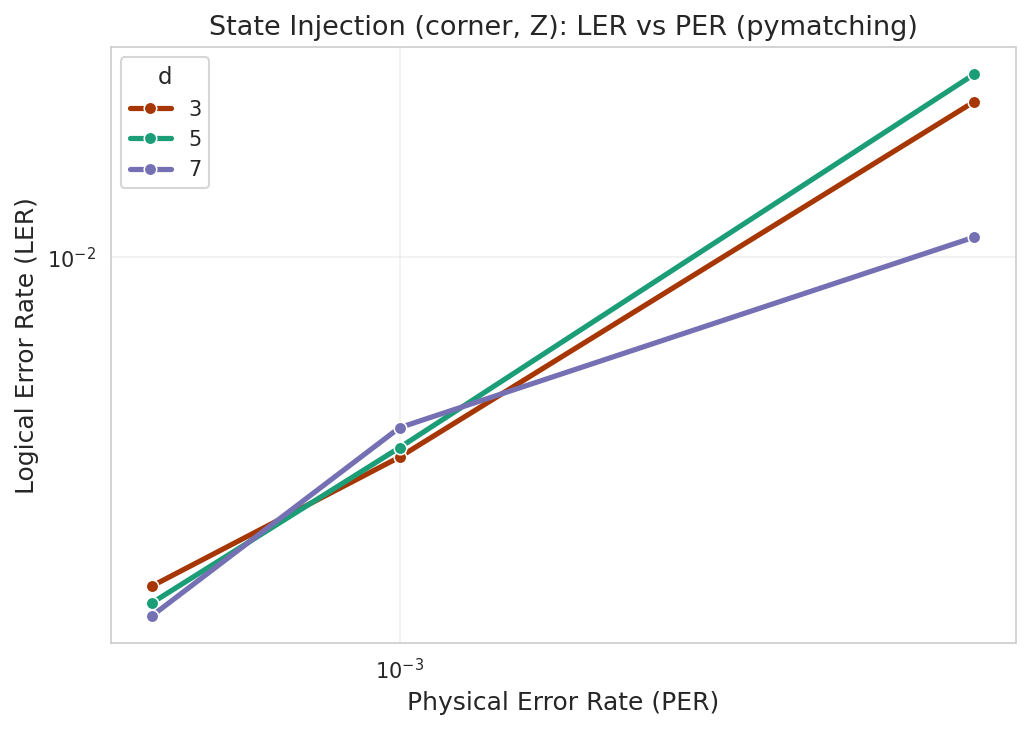

Saved plot to /home/xiang/workspace/LightStim/tests/state_injection/state_injection_ler_vs_p.png


In [ ]:
# Plot: for each (protocol, rounds), make a 1x3 panel over d, with 3 mode curves per panel.
for protocol in INJECTION_PROTOCOLS:
    for rounds in ROUNDS_LIST:
        fig, axes = plt.subplots(1, len(DISTANCES), figsize=(5 * len(DISTANCES), 4), sharey=True)
        if len(DISTANCES) == 1:
            axes = [axes]

        for ax, d in zip(axes, DISTANCES):
            sub = df[
                (df["injection_protocol"] == protocol)
                & (df["rounds"] == rounds)
                & (df["d"] == d)
            ]
            for mode in POST_SELECT_MODES:
                mode_df = sub[sub["post_select_mode"] == mode].sort_values("p")
                ax.plot(mode_df["p"], mode_df["logical_error_rate"], marker="o", label=mode)

            ax.set_xscale("log")
            ax.set_yscale("log")
            ax.set_title(f"{protocol}, rounds={rounds}, d={d}")
            ax.set_xlabel("Physical Error Rate (p)")
            ax.grid(True, which="both", alpha=0.3)

        axes[0].set_ylabel("Logical Error Rate (LER)")
        axes[-1].legend(loc="best")
        fig.suptitle(f"State Injection (inject_state=Z): full_qec vs hybrid vs full_postselection")
        fig.tight_layout()

        fig_path = out_dir / f"state_injection_eval_{protocol}_r{rounds}_ler_by_mode.png"
        fig.savefig(fig_path, dpi=180, bbox_inches="tight")
        plt.close(fig)
        print(f"Saved plot: {fig_path}")